In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv(r"C:\Users\jabhi\Downloads\loan_approval_dataset.csv")

# Strip leading/trailing spaces from column names and string values
df.columns = df.columns.str.strip()
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()
df['loan_status'] = df['loan_status'].str.strip()

# Display first few rows
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
# Check the shape of the dataset
print("Shape:", df.shape)
print()

# Check data types and non-null counts
df.info()

Shape: (4269, 13)

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 520.7 KB


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print()

# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Duplicate rows: 0


In [5]:
# Descriptive statistics
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


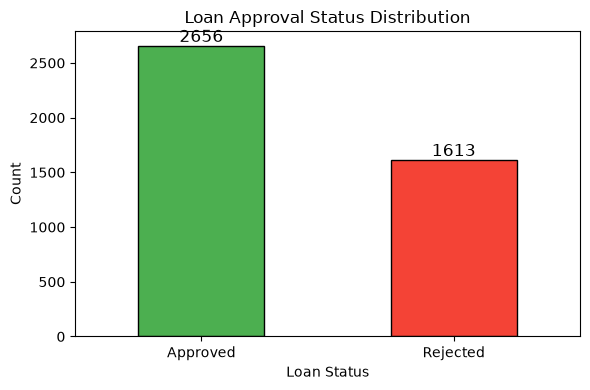

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [6]:
# Target variable distribution
plt.figure(figsize=(6, 4))
ax = df['loan_status'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'], edgecolor='black')
plt.title('Loan Approval Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()
print(df['loan_status'].value_counts())

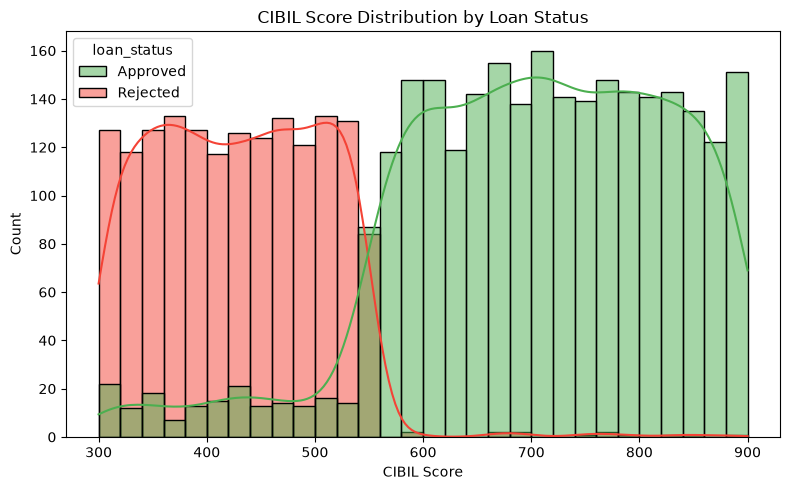

In [7]:
# CIBIL Score distribution by loan status
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='cibil_score', hue='loan_status', bins=30, kde=True,
             palette={'Approved': '#4CAF50', 'Rejected': '#F44336'})
plt.title('CIBIL Score Distribution by Loan Status')
plt.xlabel('CIBIL Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

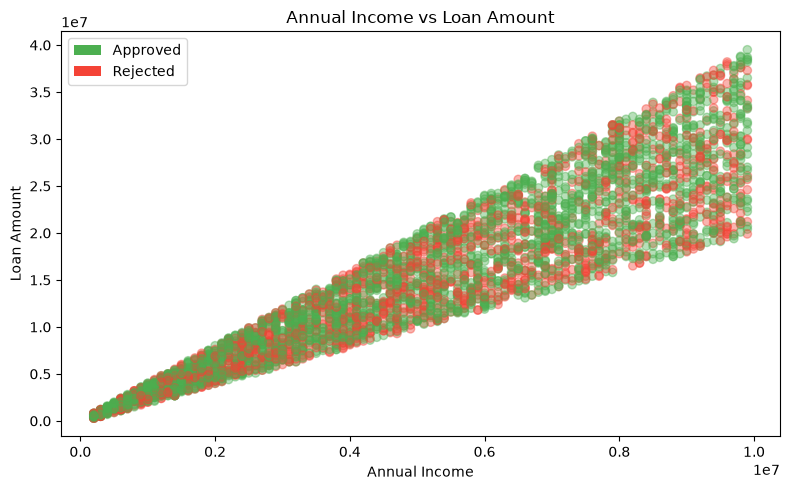

In [8]:
# Income vs Loan Amount scatter plot
plt.figure(figsize=(8, 5))
colors = df['loan_status'].map({'Approved': '#4CAF50', 'Rejected': '#F44336'})
plt.scatter(df['income_annum'], df['loan_amount'], c=colors, alpha=0.4)
plt.title('Annual Income vs Loan Amount')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='Approved'), Patch(facecolor='#F44336', label='Rejected')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

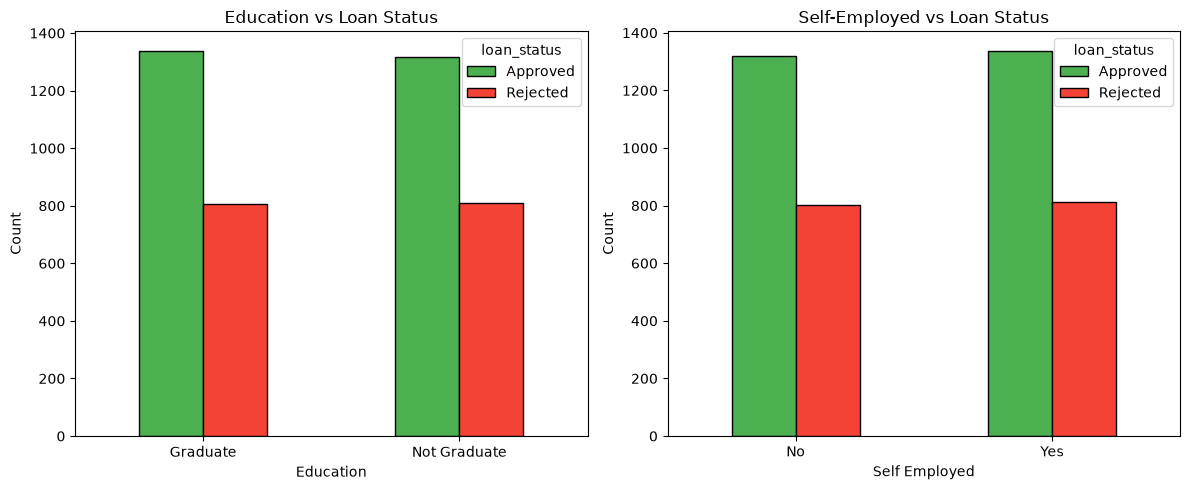

In [9]:
# Education & Self-Employed vs Loan Status
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

edu_counts = df.groupby(['education', 'loan_status']).size().unstack()
edu_counts.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Education vs Loan Status')
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

emp_counts = df.groupby(['self_employed', 'loan_status']).size().unstack()
emp_counts.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#F44336'], edgecolor='black')
axes[1].set_title('Self-Employed vs Loan Status')
axes[1].set_xlabel('Self Employed')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

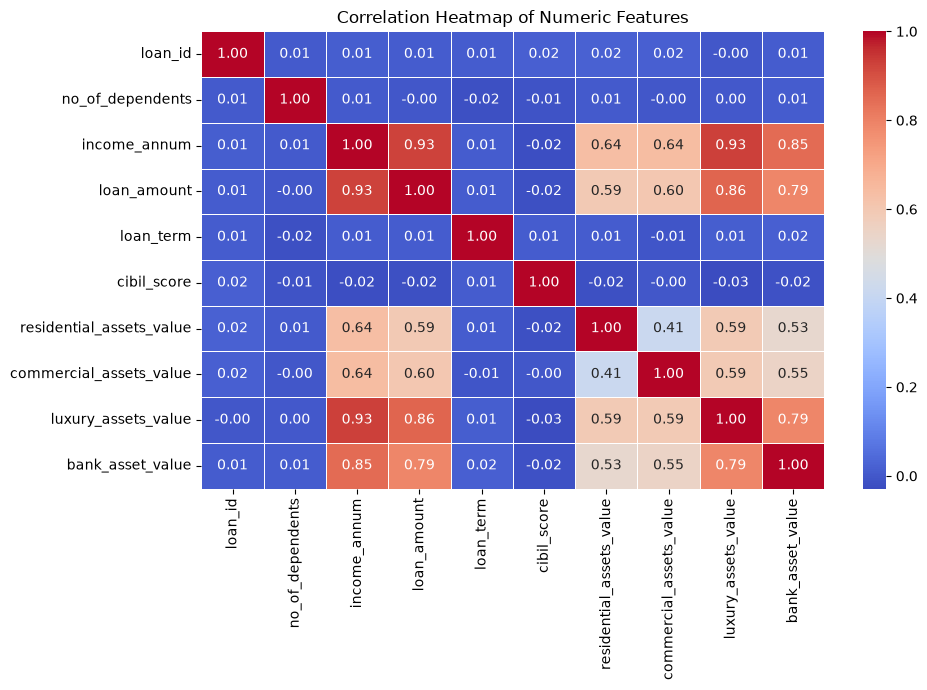

In [10]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(10, 7))
numeric_df = df.drop(columns=['education', 'self_employed', 'loan_status'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

In [11]:
# Drop loan_id (not a feature)
df.drop(columns=['loan_id'], inplace=True)

# Label encode categorical columns
le_edu = LabelEncoder()
le_emp = LabelEncoder()
le_target = LabelEncoder()

df['education'] = le_edu.fit_transform(df['education'])       # Graduate=0, Not Graduate=1
df['self_employed'] = le_emp.fit_transform(df['self_employed'])  # No=0, Yes=1
df['loan_status'] = le_target.fit_transform(df['loan_status'])   # Approved=0, Rejected=1

print("Education encoding:", dict(zip(le_edu.classes_, le_edu.transform(le_edu.classes_))))
print("Self-Employed encoding:", dict(zip(le_emp.classes_, le_emp.transform(le_emp.classes_))))
print("Loan Status encoding:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
df.head()

Education encoding: {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}
Self-Employed encoding: {'No': np.int64(0), 'Yes': np.int64(1)}
Loan Status encoding: {'Approved': np.int64(0), 'Rejected': np.int64(1)}


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [12]:
# Split features and target
X = df.drop(columns=['loan_status'])  # Features
y = df['loan_status']                 # Target

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 3415
Testing samples:  854


In [13]:
# Standardize features using StandardScaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete. Train shape:", X_train_scaled.shape)

Scaling complete. Train shape: (3415, 11)


In [14]:
# --- Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
cm_lr  = confusion_matrix(y_test, y_pred_lr)
cr_lr  = classification_report(y_test, y_pred_lr, target_names=le_target.classes_)

print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(cr_lr)

Logistic Regression Accuracy: 0.9052
              precision    recall  f1-score   support

    Approved       0.92      0.93      0.92       536
    Rejected       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



In [15]:
# --- Decision Tree ---
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_scaled, y_train)
y_pred_dt = dt_clf.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
cm_dt  = confusion_matrix(y_test, y_pred_dt)
cr_dt  = classification_report(y_test, y_pred_dt, target_names=le_target.classes_)

print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print(cr_dt)

Decision Tree Accuracy: 0.9778
              precision    recall  f1-score   support

    Approved       0.98      0.98      0.98       536
    Rejected       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [16]:
# --- Random Forest ---
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf  = confusion_matrix(y_test, y_pred_rf)
cr_rf  = classification_report(y_test, y_pred_rf, target_names=le_target.classes_)

print(f"Random Forest Accuracy: {acc_rf:.4f}")
print(cr_rf)

Random Forest Accuracy: 0.9778
              precision    recall  f1-score   support

    Approved       0.98      0.99      0.98       536
    Rejected       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



In [17]:
# --- K-Nearest Neighbors ---
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)
y_pred_knn = knn_clf.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
cm_knn  = confusion_matrix(y_test, y_pred_knn)
cr_knn  = classification_report(y_test, y_pred_knn, target_names=le_target.classes_)

print(f"KNN Accuracy: {acc_knn:.4f}")
print(cr_knn)

KNN Accuracy: 0.8923
              precision    recall  f1-score   support

    Approved       0.93      0.90      0.91       536
    Rejected       0.84      0.88      0.86       318

    accuracy                           0.89       854
   macro avg       0.88      0.89      0.89       854
weighted avg       0.89      0.89      0.89       854



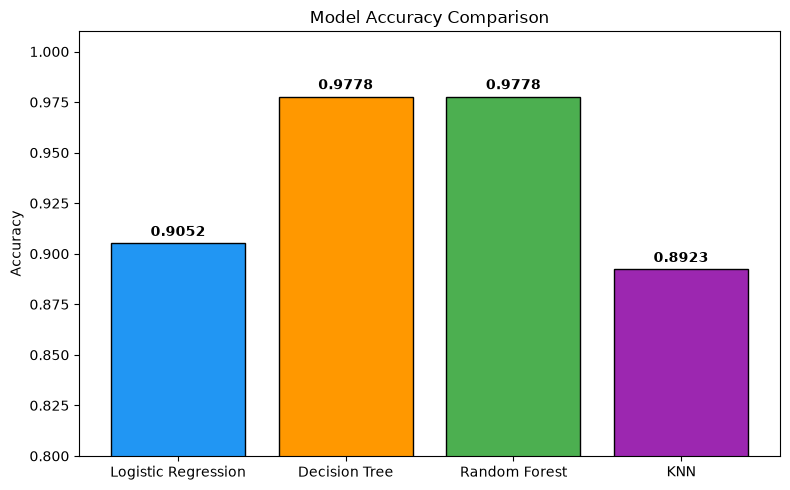

In [18]:
# Compare all model accuracies
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN']
accuracies  = [acc_lr, acc_dt, acc_rf, acc_knn]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'], edgecolor='black')
plt.ylim(0.8, 1.01)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

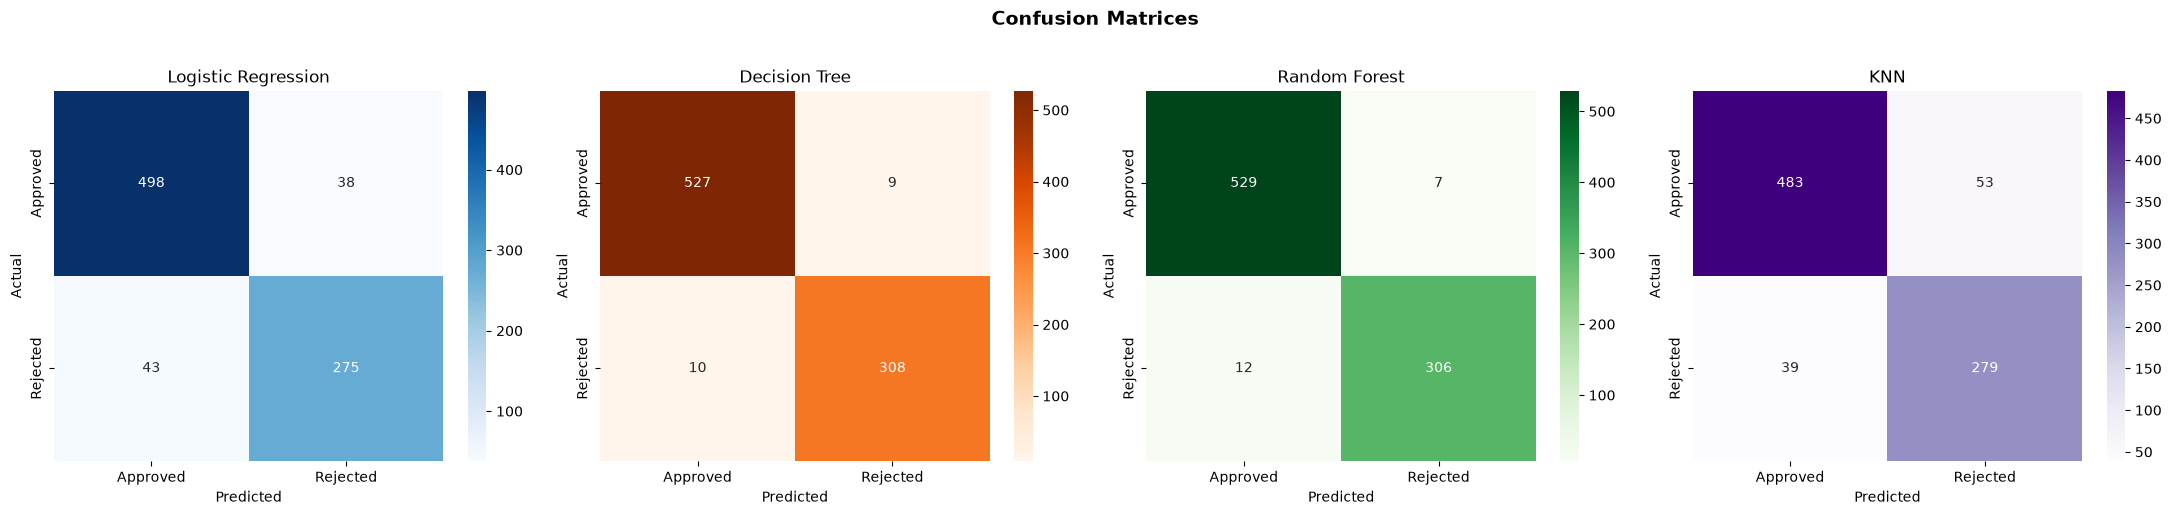

In [21]:
# Confusion matrices for all 4 models
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
cms   = [cm_lr, cm_dt, cm_rf, cm_knn]
names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN']
cmaps = ['Blues', 'Oranges', 'Greens', 'Purples']

for ax, cm, name, cmap in zip(axes, cms, names, cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=le_target.classes_, yticklabels=le_target.classes_)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

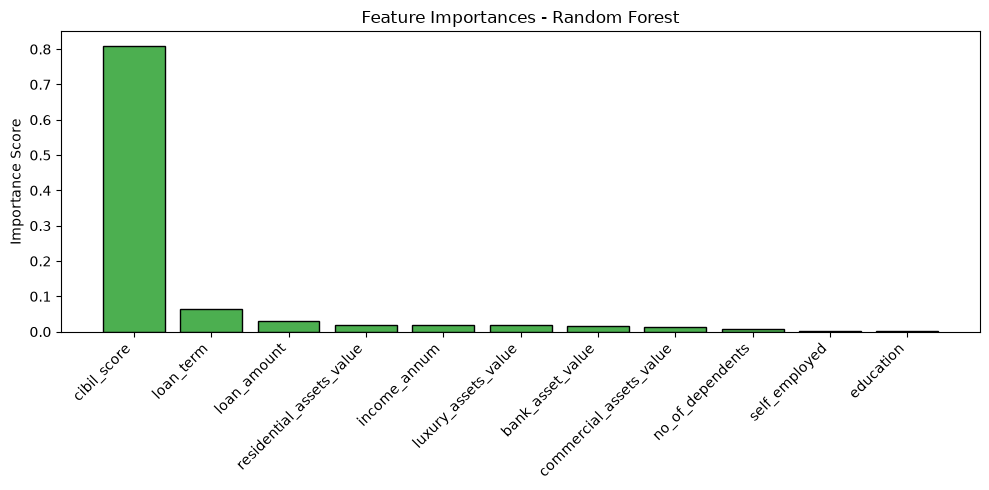

cibil_score                    0.8099
loan_term                      0.0645
loan_amount                    0.0289
residential_assets_value       0.0182
income_annum                   0.0181
luxury_assets_value            0.0177
bank_asset_value               0.0153
commercial_assets_value        0.0144
no_of_dependents               0.0084
self_employed                  0.0025
education                      0.0021


In [22]:
# Feature importance from Random Forest
feature_names = X.columns.tolist()
importances   = rf_clf.feature_importances_
indices       = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)), importances[indices], color='#4CAF50', edgecolor='black')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importances - Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

for i in indices:
    print(f"{feature_names[i]:<30} {importances[i]:.4f}")

In [23]:
# Random Forest is our best model — save it along with the scaler
import pickle

with open('loan_model.pkl', 'wb') as model_file:
    pickle.dump(rf_clf, model_file)

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("✅ loan_model.pkl saved (Random Forest)")
print("✅ scaler.pkl saved (StandardScaler)")

✅ loan_model.pkl saved (Random Forest)
✅ scaler.pkl saved (StandardScaler)


In [24]:
# Verify by loading and making a sample prediction
with open('loan_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Sample applicant: Graduate, Not self-employed, good CIBIL, decent income
sample = pd.DataFrame([{
    'no_of_dependents': 2,
    'education': 0,           # Graduate
    'self_employed': 0,       # No
    'income_annum': 5000000,
    'loan_amount': 10000000,
    'loan_term': 12,
    'cibil_score': 750,
    'residential_assets_value': 12000000,
    'commercial_assets_value': 3000000,
    'luxury_assets_value': 8000000,
    'bank_asset_value': 5000000
}])

sample_scaled = loaded_scaler.transform(sample)
prediction = loaded_model.predict(sample_scaled)
label = le_target.inverse_transform(prediction)[0]
print(f"Sample prediction: {label}")

Sample prediction: Approved
